In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv("student_scores.csv")

In [3]:
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


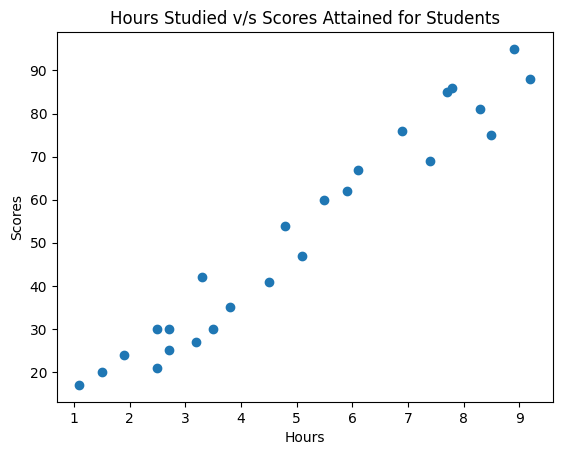

In [4]:
plt.scatter(df.Hours, df.Scores)
plt.title('Hours Studied v/s Scores Attained for Students')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.show()

In [5]:
#Using MSE for loss function:
def cost_function(m,b,points):
    cost = 0
    for i in range(len(points)):
        x = points.iloc[i].Hours
        y = points.iloc[i].Scores
        
        cost += (y - (m*x + b))**2
        cost = cost/len(points)

    return cost

In [6]:
def gradient_descent(m_now, b_now, points, L):
    m_gradient=0
    b_gradient=0
    
    n = len(points)
    
    for i in range(n):
        x = points.iloc[i].Hours
        y = points.iloc[i].Scores

        # The derivative of the loss function at each point (with respect to m and b) is added up using this loop.
        # The goal is to minimise this loss: 
        m_gradient += (-2/float(n))*( y - (m_now*x + b_now)) *(x)
        b_gradient += (-2/float(n))*( y - (m_now*x + b_now)) * (m_now)

    m = m_now - L*m_gradient
    b = b_now - L*b_gradient
    return (m,b)
        

In [7]:
# An R^2 value lies between 0 to 1. It defines how well the model fits on our data.
# The closer the R^2 value is to 1, the better the model is able to explain variance in our data.
def calc_r2(m, b, points):
    tss = 0  # Total sum of squares
    ess = 0  # Explained sum of squares
    mean = points.Scores.mean()  # Mean of actual scores
    
    for i in range(len(points)):
        # Actual value
        actual = points.iloc[i].Scores
        
        # Predicted value using the linear model: y = mx + b
        predicted = m * points.iloc[i].Hours + b
        
        # Total sum of squares: (y_i - mean)^2
        tss += (actual - mean) ** 2
        
        # Explained sum of squares: (predicted - mean)^2
        ess += (actual - predicted) ** 2

    # R² value
    r2 = 1 - (ess / tss)
    return r2


In [8]:
m = 0
b = 0
#Higher the number of epochs, the more it can optimise the value of cost function. However it also takes a larger amount of time to compute.
epochs = 2000
#This is the learning rate, and can be changed to fine-tune the model. 0.001 seems to minimise the cost function the best:
L=0.001 
for i in range(epochs):
    (m,b) = gradient_descent(m,b,df,L)
    
print(f'The calculated values for m and b are: {m}, {b}')

The calculated values for m and b are: 9.774020615775814, 2.4942472023166964


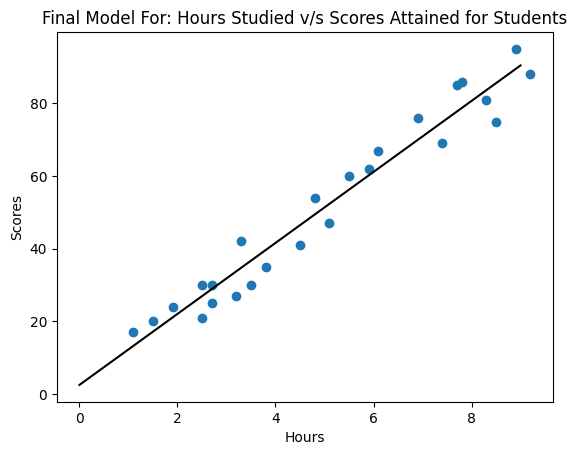

In [9]:
plt.scatter(df.Hours, df.Scores)
plt.title('Final Model For: Hours Studied v/s Scores Attained for Students')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.plot(list(range(0,10)), [m*x + b for x in range (0,10)], color="black")
plt.show()

In [10]:
print("The cost function for the values of m and b is: " , cost_function(m,b,df))

The cost function for the values of m and b is:  2.1734653057663023


In [11]:
print("The R^2 value for the given model is: ", calc_r2(m,b,df))

The R^2 value for the given model is:  0.9529481608385955
